**Parte 1**

In [2]:
import math 
import numpy as np 
import matplotlib.pyplot as plt 
import logging 
import tensorflow as tf 
import tensorflow_datasets as tfds

In [3]:
logger = tf.get_logger() 
logger.setLevel(logging.ERROR) 

In [4]:
dataset, metadata = tfds.load('mnist', as_supervised=True, with_info=True) 
train_dataset, test_dataset = dataset['train'], dataset['test'] 

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\Victor\tensorflow_datasets\mnist\incomplete.NIL2LJ_3.0.1\mnist-train.tfrecord*...:   0%|   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\Victor\tensorflow_datasets\mnist\incomplete.NIL2LJ_3.0.1\mnist-test.tfrecord*...:   0%|    …

Dataset mnist downloaded and prepared to C:\Users\Victor\tensorflow_datasets\mnist\3.0.1. Subsequent calls will reuse this data.


In [5]:
class_names = [ 
'Cero', 'Uno', 'Dos', 'Tres', 'Cuatro', 'Cinco', 'Seis', 'Siete', 
'Ocho', 'Nueve' 
]

In [6]:
num_train_examples = metadata.splits['train'].num_examples #60 mil datos train 
num_test_examples = metadata.splits['test'].num_examples #10 mil datos test 

In [8]:
#Normalizar: Numeros de 0 a 255, que sean de 0 a 1 
def normalize(images, labels): 
    images = tf.cast(images, tf.float32) 
    images /= 255 
    return images, labels

In [9]:
train_dataset = train_dataset.map(normalize) 
test_dataset = test_dataset.map(normalize) 

In [10]:
#Estructura de la red 
model = tf.keras.Sequential([ 
tf.keras.layers.Flatten(input_shape=(28,28,1)), #Capa de entrada 
tf.keras.layers.Dense(64, activation=tf.nn.relu), #Capas oculta 
tf.keras.layers.Dense(64, activation=tf.nn.relu), #Capas oculta 
tf.keras.layers.Dense(10, activation=tf.nn.softmax) #para clasificacion 
]) 

C:\Users\Victor\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
#Función que compila el modelo 
model.compile( 
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy'] 
) 

In [13]:
#Aprendizaje por lotes de 32 cada lote 
BATCHSIZE = 32 
train_dataset = train_dataset.repeat().shuffle(num_train_examples).batch(BATCHSIZE) 
test_dataset = test_dataset.batch(BATCHSIZE) 

In [14]:
#Realizar el aprendizaje 
model.fit( 
train_dataset, epochs=5, 
steps_per_epoch=math.ceil(num_train_examples/BATCHSIZE) 
) 

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9195 - loss: 0.2714
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9637 - loss: 0.1186
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9726 - loss: 0.0892
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9776 - loss: 0.0699
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9815 - loss: 0.0583


In [15]:
#Evaluar nuestro modelo ya entrenado, contra el dataset de pruebas 
test_loss, test_accuracy = model.evaluate( 
test_dataset, steps=math.ceil(num_test_examples/32) 
) 
#Imprime los resultados de precisión 
print("Resultado en las pruebas: ", test_accuracy) 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9703 - loss: 0.1020
Resultado en las pruebas:  0.970300018787384


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


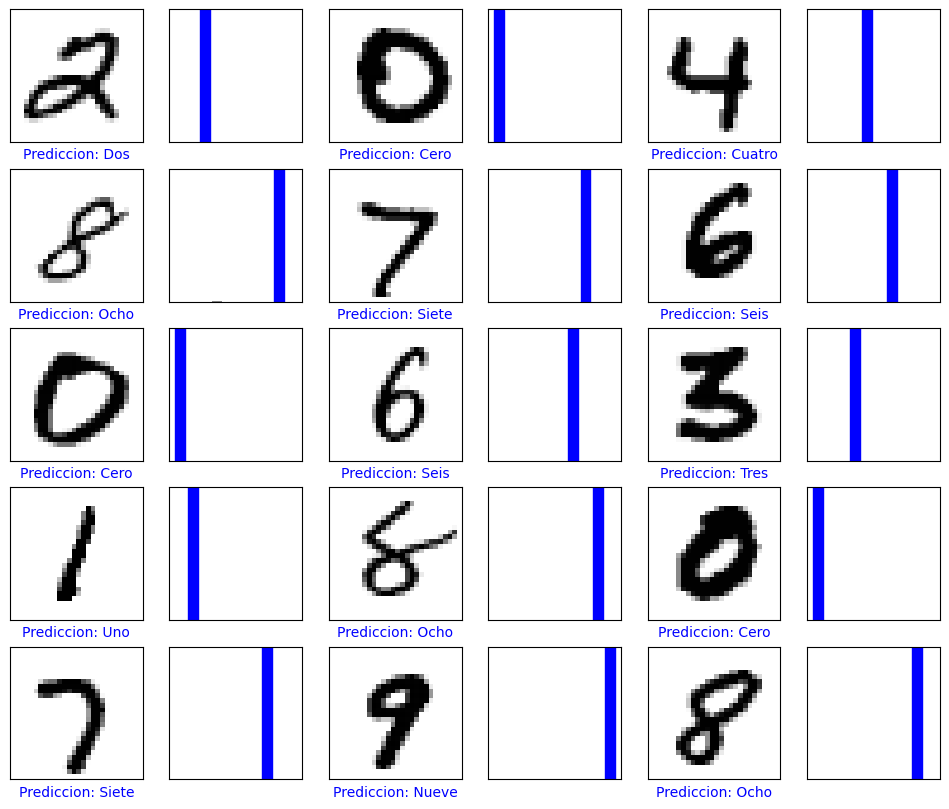

In [18]:
for test_images, test_labels in test_dataset.take(1): 
  test_images = test_images.numpy() 
  test_labels = test_labels.numpy() 
  predictions = model.predict(test_images) 
 
def plot_image(i, predictions_array, true_labels, images): 
  predictions_array, true_label, img = predictions_array[i], true_labels[i], images[i] 
  plt.grid(False) 
  plt.xticks([]) 
  plt.yticks([]) 
 
  plt.imshow(img[...,0], cmap=plt.cm.binary) 
 
  predicted_label = np.argmax(predictions_array) 
  if predicted_label == true_label: 
    color = 'blue' 
  else: 
    color = 'red' 
 
  plt.xlabel("Prediccion: {}".format(class_names[predicted_label]), color=color) 
 
def plot_value_array(i, predictions_array, true_label): 
  predictions_array, true_label = predictions_array[i], true_label[i] 
  plt.grid(False) 
  plt.xticks([]) 
  plt.yticks([]) 
  thisplot = plt.bar(range(10), predictions_array, color="#888888") 
  plt.ylim([0,1]) 
  predicted_label = np.argmax(predictions_array) 
 
  thisplot[predicted_label].set_color('red') 
  thisplot[true_label].set_color('blue')

num_rows = 5
num_cols = 3
num_images = num_rows * num_cols

plt.figure(figsize=(2*2*num_cols, 2*num_rows))

for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions, test_labels, test_images)

    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions, test_labels)

plt.show()

In [26]:
#Guardar el modelo
model.save("modelo_mnist.h5")
model.save("modelo_mnist.keras")
print("Modelo guardado")

Modelo guardado


**Parte 2**

**Instrucciones para que funcione la parte 2**

Se debe de correr todas las celdas de la parte 2.
La última celda inicia el servidor, una vez iniciado, se debe de abrir el html de index en el navegador.
Para detener el servidor, en la última celda se debe detener el kernel.
Para volver a levantar el servidor, se debe de volver a correr todas las celdas de la parte 2 y actualizar la ventana del index.html

In [6]:
#Crear el servidor en jupyter
from urllib import parse
from http.server import HTTPServer, BaseHTTPRequestHandler
import numpy as np
import keras
import tensorflow as tf
@keras.saving.register_keras_serializable()
def softmax_v2(x):
    return tf.nn.softmax(x)

In [7]:
model = tf.keras.models.load_model(
    "modelo_mnist.h5",
    custom_objects={"softmax_v2": softmax_v2},
    compile=False
)

print("Modelo cargado correctamente")

Modelo cargado correctamente


In [8]:
#Creando servidor

In [9]:
class SimpleHTTPRequestHandler(BaseHTTPRequestHandler):

    def do_POST(self):
        print("Peticion recibida")

        content_length = int(self.headers['Content-Length'])
        data = self.rfile.read(content_length)

        data = data.decode().replace('pixeles=', '')
        data = parse.unquote(data)

        arr = np.fromstring(data, np.float32, sep=",")
        print("Pixeles:", len(arr))

        arr = arr.reshape(28,28)
        arr = arr / 255.0
        arr = 1 - arr
        arr = arr.reshape(1,28,28,1)
        print("Max:", np.max(arr))
        print("Min:", np.min(arr))

        prediction_values = model.predict(arr, batch_size=1)

        prediction = str(np.argmax(prediction_values))

        print("Prediccion:", prediction)

        self.send_response(200)
        self.send_header("Access-Control-Allow-Origin", "*")
        self.end_headers()

        self.wfile.write(prediction.encode())

In [5]:
#Iniciar servidor
print("Servidor iniciado en http://localhost:8000")

server = HTTPServer(('localhost',8000), SimpleHTTPRequestHandler)

server.serve_forever()

Servidor iniciado en http://localhost:8000
Peticion recibida
Pixeles: 784
Max: 1.0
Min: 0.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Prediccion: 6


127.0.0.1 - - [10/Mar/2026 12:10:10] "POST / HTTP/1.1" 200 -


Peticion recibida
Pixeles: 784
Max: 1.0
Min: 0.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Prediccion: 2


127.0.0.1 - - [10/Mar/2026 12:10:21] "POST / HTTP/1.1" 200 -


Peticion recibida
Pixeles: 784
Max: 1.0
Min: 0.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Prediccion: 8


...

Peticion recibida
Pixeles: 784
Max: 1.0
Min: 0.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Prediccion: 2


127.0.0.1 - - [10/Mar/2026 12:18:40] "POST / HTTP/1.1" 200 -


Peticion recibida
Pixeles: 784
Max: 1.0
Min: 0.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Prediccion: 7


127.0.0.1 - - [10/Mar/2026 12:18:43] "POST / HTTP/1.1" 200 -


KeyboardInterrupt: 